# 15. Vectors, Matrices and Norms

**Part 3: Direct Methods for Linear Systems**

## Learning objectives

By the end of this lesson you will be able to:

1. Read $A\mathbf{x}$ as a **linear combination of the columns of $A$**, and say what that
   buys you.
2. Read the product $AB$ three ways, and explain which view makes which fact obvious.
3. State the three **norm axioms** and check numerically that a candidate satisfies them.
4. Compute the vector $p$-norms and recognise their unit balls on sight.
5. Define an **induced matrix norm** as the largest stretching factor, and use the closed
   forms for $p = 1, 2, \infty$.
6. Explain why the **Frobenius norm is not induced**, in one line.
7. Use **submultiplicativity** to build error bounds, and measure how pessimistic they are.
8. Explain why the **spectral radius is not a norm**, and why it is nonetheless the quantity
   that decides convergence.
9. Turn a bound on an input perturbation into a bound on the output. This is the machinery
   behind every error bound in Parts 3 to 6.

## Prerequisites

Lesson 06 (conditioning, stability, forward and backward error), which this lesson gives the
vocabulary to state precisely. Lesson 08 (cost and memory) for the matrix product experiment.
Basic linear algebra: matrices, vectors, matrix multiplication.

---

## 1. A matrix is a linear map, and $A\mathbf{x}$ is a combination of columns

Most first courses define $A\mathbf{x}$ entry by entry: entry $i$ is row $i$ of $A$ dotted with
$\mathbf{x}$. That is correct and it is the least useful way to think about it.

Write $A$ by its columns, $A = [\mathbf{a}_1 \mid \mathbf{a}_2 \mid \cdots \mid \mathbf{a}_n]$.
Then

$$A\mathbf{x} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2 + \cdots + x_n\mathbf{a}_n.$$

$A\mathbf{x}$ is a **linear combination of the columns of $A$**, with the entries of
$\mathbf{x}$ as the coefficients.

Three facts fall out immediately, and each of them is used constantly later:

| Fact | Why it is immediate |
|---|---|
| The **range** of $A$ is the span of its columns | $A\mathbf{x}$ is a combination of columns, so it cannot leave their span |
| $A\mathbf{x} = \mathbf{b}$ is solvable exactly when $\mathbf{b}$ is in that span | solvable means $\mathbf{b}$ is expressible as such a combination |
| **Rank** is the number of independent columns | the span has that dimension |

None of those is obvious from the row-by-row definition. The second one is the entire setup of
least squares in lesson 29: when $\mathbf{b}$ is *not* in the span, you take the closest point
that is.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import linalg as la, orthogonality as og


def show_column_view(A, x):
    """Print A @ x as a sum of scaled columns, for a matrix of any shape.

    Every dimension is read off A itself, so this works for a 3 by 3, a 2 by 5, or a
    1 by 1. Nothing here knows the size of the example below.
    """
    A = np.atleast_2d(np.asarray(A, dtype=float))
    x = np.asarray(x, dtype=float).ravel()
    if A.shape[1] != x.size:
        raise ValueError(f"A has {A.shape[1]} columns but x has {x.size} entries")

    print(f"A is {A.shape[0]} by {A.shape[1]}, x has {x.size} entries")
    for j in range(A.shape[1]):                       # NOT a hardcoded count
        print(f"   {x[j]:>6.2f} * column {j} = {np.round(x[j] * A[:, j], 4)}")
    total = la.matvec_by_columns(A, x)
    print(f"   {'sum':>6}{'':>15} = {np.round(total, 4)}")
    np.testing.assert_allclose(total, A @ x, atol=1e-12)
    return total


# The DATA is a specific example, as it has to be. The CODE above is not.
A = np.array([[1.0, 2.0, 0.0],
              [3.0, 1.0, 1.0],
              [0.0, 4.0, 2.0]])
x = np.array([2.0, -1.0, 3.0])
show_column_view(A, x)

print("\nthe same code on three completely different shapes:\n")
rng_demo = np.random.default_rng(15)
for shape in [(2, 5), (5, 2), (1, 1)]:
    print(f"-- {shape[0]} by {shape[1]} --")
    show_column_view(rng_demo.standard_normal(shape),
                     rng_demo.standard_normal(shape[1]))
    print()

print("identical logic every time. the point is not the answer, it is that")
print("the answer LIVES IN THE SPAN OF THE COLUMNS and cannot leave it.")

A is 3 by 3, x has 3 entries
     2.00 * column 0 = [2. 6. 0.]
    -1.00 * column 1 = [-2. -1. -4.]
     3.00 * column 2 = [0. 3. 6.]
      sum                = [0. 8. 2.]

the same code on three completely different shapes:

-- 2 by 5 --
A is 2 by 5, x has 5 entries
     0.73 * column 0 = [-1.0427  0.5883]
    -0.54 * column 1 = [0.5048 0.778 ]
     0.20 * column 2 = [0.0794 0.2049]
     0.21 * column 3 = [-0.1127 -0.1281]
     0.33 * column 4 = [0.1732 0.69  ]
      sum                = [-0.398   2.1332]

-- 5 by 2 --
A is 5 by 2, x has 2 entries
    -0.61 * column 0 = [-0.8545 -1.0185  0.109   0.9571 -0.4238]
     0.08 * column 1 = [ 0.0414  0.0493 -0.1186  0.0159  0.1123]
      sum                = [-0.813  -0.9691 -0.0096  0.973  -0.3115]

-- 1 by 1 --
A is 1 by 1, x has 1 entries
    -0.42 * column 0 = [0.3433]
      sum                = [0.3433]

identical logic every time. the point is not the answer, it is that
the answer LIVES IN THE SPAN OF THE COLUMNS and cannot leave it.


### Rank, seen as a statement about columns

If the columns are dependent, the span is smaller than you might expect, and the range of $A$
is a lower-dimensional set. Everything $A$ can produce lies in that set.

In [3]:
def explore_range(M, n_samples=500, seed=0):
    """Sample M @ x for random x and report the dimension of the cloud that comes out.

    Sizes come from M.shape, and the number of singular values examined comes from the
    result, so this measures the range of any matrix of any shape.
    """
    M = np.atleast_2d(np.asarray(M, dtype=float))
    rows, cols = M.shape
    gen = np.random.default_rng(seed)
    outputs = np.array([M @ gen.standard_normal(cols) for _ in range(n_samples)])
    s = np.linalg.svd(outputs - outputs.mean(axis=0), compute_uv=False)

    tol = 1e-10 * (s[0] if s.size else 1.0)
    effective = int(np.sum(s > tol))
    print(f"   M is {rows} by {cols}, rank {np.linalg.matrix_rank(M)}")
    print(f"   singular values of {n_samples} outputs: {np.round(s, 6)}")
    print(f"   {effective} of {s.size} are above the noise floor, so the outputs fill "
          f"a {effective}-dimensional set")
    return s, effective


# third column is the sum of the first two, so the columns span only a plane
B = np.array([[1.0, 2.0, 3.0],
              [0.0, 1.0, 1.0],
              [2.0, 1.0, 3.0]])
print("B =\n", B)
print(f"\ncolumn 2 - (column 0 + column 1) = {B[:, 2] - (B[:, 0] + B[:, 1])}\n")
s_B, dim_B = explore_range(B)
assert dim_B == np.linalg.matrix_rank(B) < B.shape[1]

print("\nthe same measurement on other shapes and ranks:\n")
rng_r = np.random.default_rng(4)
for label, M in [
    ("full rank square", rng_r.standard_normal((4, 4))),
    ("tall, full column rank", rng_r.standard_normal((7, 3))),
    ("wide, full row rank", rng_r.standard_normal((3, 7))),
    ("rank one, tall and wide", np.outer(rng_r.standard_normal(6),
                                        rng_r.standard_normal(4))),
]:
    print(f"-- {label} --")
    _, d = explore_range(M, n_samples=400, seed=1)
    assert d == np.linalg.matrix_rank(M)
    print()

print("in every case the cloud's dimension equals the RANK, never the number of")
print("rows. that is the column view: outputs cannot leave the column span.")

B =
 [[1. 2. 3.]
 [0. 1. 1.]
 [2. 1. 3.]]

column 2 - (column 0 + column 1) = [0. 0. 0.]

   M is 3 by 3, rank 2
   singular values of 500 outputs: [119.528002  25.959423   0.      ]
   2 of 3 are above the noise floor, so the outputs fill a 2-dimensional set

the same measurement on other shapes and ranks:

-- full rank square --
   M is 4 by 4, rank 4
   singular values of 400 outputs: [66.863171 51.672955 32.594008  2.177039]
   4 of 4 are above the noise floor, so the outputs fill a 4-dimensional set

-- tall, full column rank --
   M is 7 by 3, rank 3
   singular values of 400 outputs: [73.478276 53.791676 31.933731  0.        0.        0.        0.      ]
   3 of 7 are above the noise floor, so the outputs fill a 3-dimensional set

-- wide, full row rank --
   M is 3 by 7, rank 3
   singular values of 400 outputs: [61.211087 39.311993 19.677978]
   3 of 3 are above the noise floor, so the outputs fill a 3-dimensional set

-- rank one, tall and wide --
   M is 6 by 4, rank 1
   si

**What to take from this.** A rank-deficient matrix does not merely have a zero determinant. It
**cannot produce** most vectors, no matter what input you give it. That is a much more useful
statement, and it is the column view that makes it visible.

## 2. Three ways to read $AB$

The same regrouping applies to a matrix product, and here there are three natural readings.

| View | Formula | What it makes obvious |
|---|---|---|
| **inner product** | $(AB)_{ij} = \mathbf{a}_i^T\mathbf{b}_j$ | the textbook definition, one entry at a time |
| **column** | column $j$ of $AB$ is $A\mathbf{b}_j$ | every column of $AB$ is in the range of $A$, so $\operatorname{rank}(AB) \le \operatorname{rank}(A)$ |
| **outer product** | $AB = \sum_k \mathbf{a}_k\mathbf{b}_k^T$ | **every product is a sum of rank-one pieces** |

The third is the one that matters most later. It is the form the SVD puts a matrix into
(lesson 41), the form low-rank approximation truncates (lesson 43), and the form Gram-Schmidt
builds up (lesson 30).

In [4]:
rng2 = np.random.default_rng(7)
A2 = rng2.standard_normal((5, 4))
B2 = rng2.standard_normal((4, 3))
reference = A2 @ B2

views = {
    "inner products": la.matmul_by_inner_products(A2, B2),
    "by columns":     la.matmul_by_columns(A2, B2),
    "outer products": la.matmul_by_outer_products(A2, B2),
}
print(f"{'view':>18} {'max difference from A @ B':>28}")
print("-" * 48)
for name, M in views.items():
    print(f"{name:>18} {np.abs(M - reference).max():>28.3e}")
    np.testing.assert_allclose(M, reference, atol=1e-13)

print("\nmathematically identical. the three differ only in the ORDER of the")
print("same additions, so they agree to a few ulps and never exactly.")

              view    max difference from A @ B
------------------------------------------------
    inner products                    4.441e-16
        by columns                    4.441e-16
    outer products                    2.220e-16

mathematically identical. the three differ only in the ORDER of the
same additions, so they agree to a few ulps and never exactly.


### The outer product view, seen directly

In [5]:
print("AB as a running sum of rank-one pieces:\n")
print(f"{'terms used':>12} {'rank of partial sum':>21} {'||partial - AB||':>19}")
print("-" * 56)
partial = np.zeros_like(reference)
for k in range(A2.shape[1]):
    partial = partial + np.outer(A2[:, k], B2[k, :])
    print(f"{k+1:>12} {np.linalg.matrix_rank(partial):>21} "
          f"{np.linalg.norm(partial - reference):>19.3e}")

print("\neach term adds at most 1 to the rank, and after 4 terms we have AB")
print("exactly. a rank-4 matrix is a sum of 4 rank-one matrices, and that is")
print("what 'rank' means. lesson 43 asks what happens if you stop early.")
assert np.linalg.norm(partial - reference) < 1e-13

AB as a running sum of rank-one pieces:

  terms used   rank of partial sum    ||partial - AB||
--------------------------------------------------------
           1                     1           6.483e+00
           2                     2           6.475e+00
           3                     3           3.544e+00
           4                     3           2.779e-16

each term adds at most 1 to the rank, and after 4 terms we have AB
exactly. a rank-4 matrix is a sum of 4 rank-one matrices, and that is
what 'rank' means. lesson 43 asks what happens if you stop early.


**What to take from this.** These are not three algorithms with different answers. They are
three ways of grouping the same additions, and the grouping is free to choose. Lesson 08
measured that the grouping changes the runtime by an order of magnitude because of memory
access. Here the point is that it also changes which facts are obvious.

## 3. Norms: measuring the size of a vector

To say "the error is small" you need a single number measuring the size of a vector. A **norm**
is any function $\|\cdot\|$ satisfying three axioms.

> **Definition 15.1 (Norm).** A function $\|\cdot\| : \mathbb{R}^n \to \mathbb{R}$ is a norm
> when for all $\mathbf{x}, \mathbf{y}$ and all scalars $c$:
>
> 1. **Positivity.** $\|\mathbf{x}\| \ge 0$, with $\|\mathbf{x}\| = 0$ only if
>    $\mathbf{x} = \mathbf{0}$.
> 2. **Absolute homogeneity.** $\|c\mathbf{x}\| = |c|\,\|\mathbf{x}\|$.
> 3. **Triangle inequality.** $\|\mathbf{x} + \mathbf{y}\| \le \|\mathbf{x}\| + \|\mathbf{y}\|$.

The family we use throughout is the $p$-norms:

$$\|\mathbf{x}\|_p = \left(\sum_i |x_i|^p\right)^{1/p},
\qquad \|\mathbf{x}\|_\infty = \max_i |x_i|.$$

Three of them get used constantly:

| Norm | Formula | When it is the right one |
|---|---|---|
| $\|\cdot\|_1$ | $\sum_i \lvert x_i\rvert$ | total error across all components; also the norm that promotes sparsity |
| $\|\cdot\|_2$ | $\sqrt{\sum_i x_i^2}$ | physical length; the only $p$-norm from an inner product |
| $\|\cdot\|_\infty$ | $\max_i \lvert x_i\rvert$ | worst single component; usually the honest one for error |

In [6]:
x3 = np.array([3.0, -4.0, 12.0])
print(f"x = {x3}\n")
print(f"{'p':>6} {'||x||_p':>12} {'numpy':>12}")
print("-" * 32)
for p in [1, 2, 3, 10, np.inf]:
    mine = la.vector_norm(x3, p)
    print(f"{str(p):>6} {mine:>12.8f} {np.linalg.norm(x3, p):>12.8f}")
    np.testing.assert_allclose(mine, np.linalg.norm(x3, p))

print()
print("notice the norms DECREASE as p grows, and settle on the max entry, 12.")
print("that is general: ||x||_inf <= ... <= ||x||_2 <= ||x||_1 for every x.")
assert la.vector_norm(x3, 1) >= la.vector_norm(x3, 2) >= la.vector_norm(x3, np.inf)

x = [ 3. -4. 12.]

     p      ||x||_p        numpy
--------------------------------
     1  19.00000000  19.00000000
     2  13.00000000  13.00000000
     3  12.20705495  12.20705495
    10  12.00002147  12.00002147
   inf  12.00000000  12.00000000

notice the norms DECREASE as p grows, and settle on the max entry, 12.
that is general: ||x||_inf <= ... <= ||x||_2 <= ||x||_1 for every x.


### Checking the axioms rather than trusting them

In [7]:
rng3 = np.random.default_rng(11)

print("the axioms must hold at EVERY length, so check several rather than one")
print()
print(f"{'length':>8} {'norm':>10} {'positivity':>13} {'homogeneity':>14} {'triangle':>12}")
print("-" * 62)
for dim in (1, 2, 6, 33):
    sample = [rng3.standard_normal(dim) for _ in range(8)] + [np.zeros(dim)]
    for p, label in [(1, "1-norm"), (2, "2-norm"), (np.inf, "inf-norm"), (3, "3-norm")]:
        v = la.check_norm_axioms(lambda z, p=p: la.vector_norm(z, p), sample)
        print(f"{dim:>8} {label:>10} {v['positivity']:>13.2e} {v['homogeneity']:>14.2e} "
              f"{v['triangle']:>12.2e}")
        assert max(v.values()) < 1e-13
    print()

# kept for the next cell, which needs a sample of one fixed length
SAMPLE_DIM = 6
sample = [rng3.standard_normal(SAMPLE_DIM) for _ in range(8)] + [np.zeros(SAMPLE_DIM)]

print("every violation is at roundoff, at every length, so all four really are")
print("norms. this is a check, not a proof, but a failed check is a proof of failure.")

the axioms must hold at EVERY length, so check several rather than one

  length       norm    positivity    homogeneity     triangle
--------------------------------------------------------------
       1     1-norm      0.00e+00       0.00e+00     0.00e+00
       1     2-norm      0.00e+00       0.00e+00     0.00e+00
       1   inf-norm      0.00e+00       0.00e+00     0.00e+00
       1     3-norm      0.00e+00       1.96e-16     0.00e+00

       2     1-norm      0.00e+00       2.11e-16     1.30e-16
       2     2-norm      0.00e+00       2.03e-16     0.00e+00
       2   inf-norm      0.00e+00       0.00e+00     0.00e+00
       2     3-norm      0.00e+00       2.14e-16     0.00e+00

       6     1-norm      0.00e+00       3.16e-16     0.00e+00
       6     2-norm      0.00e+00       1.81e-16     0.00e+00
       6   inf-norm      0.00e+00       0.00e+00     0.00e+00
       6     3-norm      0.00e+00       1.52e-16     0.00e+00

      33     1-norm      0.00e+00       2.18e-16     0.0

Now a function that is **not** a norm, to see what the check catches:

In [8]:
def fake(z):
    """The 'p = 0.5 norm'. It satisfies two axioms out of three."""
    return float(np.sum(np.abs(z) ** 0.5) ** 2)


v = la.check_norm_axioms(fake, sample)
print("the p = 0.5 'norm':")
for k, val in v.items():
    print(f"   {k:>12}: {val:.3e}")
print()
print("positivity and homogeneity pass. the TRIANGLE INEQUALITY fails, and by")
print("a lot. for p < 1 the unit ball is not convex, and convexity of the ball")
print("is exactly what the triangle inequality says.")
assert v["triangle"] > 0.01

the p = 0.5 'norm':
     positivity: 0.000e+00
    homogeneity: 5.274e-16
       triangle: 6.531e-02

positivity and homogeneity pass. the TRIANGLE INEQUALITY fails, and by
a lot. for p < 1 the unit ball is not convex, and convexity of the ball
is exactly what the triangle inequality says.


### The unit ball *is* the norm

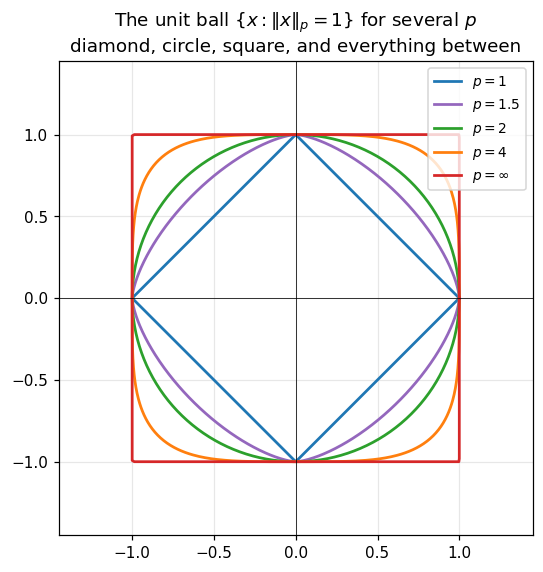

the diamond sits inside the circle sits inside the square.
that nesting IS the inequality ||x||_inf <= ||x||_2 <= ||x||_1,
read geometrically: a smaller ball means a larger norm.


In [9]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))
for p, colour, label in [(1, "C0", "$p = 1$"), (1.5, "C4", "$p = 1.5$"),
                         (2, "C2", "$p = 2$"), (4, "C1", "$p = 4$"),
                         (np.inf, "C3", r"$p = \infty$")]:
    pts = la.unit_ball_points(p, 600)
    ax.plot(pts[:, 0], pts[:, 1], color=colour, lw=1.8, label=label)

ax.set_aspect("equal")
ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_title("The unit ball $\\{x : \\|x\\|_p = 1\\}$ for several $p$\n"
             "diamond, circle, square, and everything between")
ax.legend(fontsize=9, loc="upper right")
plt.show()

print("the diamond sits inside the circle sits inside the square.")
print("that nesting IS the inequality ||x||_inf <= ||x||_2 <= ||x||_1,")
print("read geometrically: a smaller ball means a larger norm.")

### Norm equivalence, and why the constants matter

All norms on $\mathbb{R}^n$ are **equivalent**: for any two of them there are constants
$c, C > 0$ with

$$c\|\mathbf{x}\|_q \le \|\mathbf{x}\|_p \le C\|\mathbf{x}\|_q \quad\text{for all }\mathbf{x}.$$

So a sequence converging in one norm converges in all of them, which is why nobody says which
norm they mean when they say "converges" in finite dimensions.

The catch is that **the constants grow with $n$**.

In [10]:
print("sharp constants for  c ||x||_q <= ||x||_p <= C ||x||_q\n")
print(f"{'n':>6} {'||x||_1 <= C ||x||_inf':>26} {'||x||_2 <= C ||x||_inf':>26}")
print("-" * 62)
for n in [2, 10, 100, 10000]:
    c1, C1 = la.norm_equivalence_constants(n, 1, np.inf)
    c2, C2 = la.norm_equivalence_constants(n, 2, np.inf)
    print(f"{n:>6} {f'C = {C1:g}':>26} {f'C = {C2:g}':>26}")

print()
print("at n = 10000 the 1-norm can be 10000 times the infinity norm.")
print("so 'equivalent' is a statement about FIXED n. in a problem where n")
print("grows, which is every PDE problem in part 11, the choice of norm")
print("changes what a bound means.")

# the constants are attained, not merely valid
n = 100
ones = np.ones(n)
print(f"\nx = all ones in R^{n}:")
print(f"   ||x||_1 / ||x||_inf = {la.vector_norm(ones,1)/la.vector_norm(ones,np.inf):g}, "
      f"the bound C = {n} is attained exactly")
e1 = np.zeros(n); e1[0] = 1.0
print(f"x = e_1: ||x||_1 / ||x||_inf = "
      f"{la.vector_norm(e1,1)/la.vector_norm(e1,np.inf):g}, the other end")
assert la.vector_norm(ones, 1) / la.vector_norm(ones, np.inf) == n

sharp constants for  c ||x||_q <= ||x||_p <= C ||x||_q

     n     ||x||_1 <= C ||x||_inf     ||x||_2 <= C ||x||_inf
--------------------------------------------------------------
     2                      C = 2                C = 1.41421
    10                     C = 10                C = 3.16228
   100                    C = 100                     C = 10
 10000                  C = 10000                    C = 100

at n = 10000 the 1-norm can be 10000 times the infinity norm.
so 'equivalent' is a statement about FIXED n. in a problem where n
grows, which is every PDE problem in part 11, the choice of norm
changes what a bound means.

x = all ones in R^100:
   ||x||_1 / ||x||_inf = 100, the bound C = 100 is attained exactly
x = e_1: ||x||_1 / ||x||_inf = 1, the other end


## 4. Induced matrix norms: the largest stretch

A matrix norm should measure how much the matrix can **stretch** a vector. That is exactly the
definition.

> **Definition 15.2 (Induced norm).** For a vector norm $\|\cdot\|_p$, the induced matrix norm
> is
> $$\|A\|_p = \max_{\mathbf{x} \ne \mathbf{0}} \frac{\|A\mathbf{x}\|_p}{\|\mathbf{x}\|_p}
> = \max_{\|\mathbf{x}\|_p = 1} \|A\mathbf{x}\|_p.$$

Read directly: **$\|A\|$ is the worst stretching factor over all directions.**

That definition is a maximisation over infinitely many directions, so it looks expensive. For
three values of $p$ it has a closed form:

$$\|A\|_1 = \max_j \sum_i |a_{ij}| \ \text{(max column sum)}, \qquad
\|A\|_\infty = \max_i \sum_j |a_{ij}| \ \text{(max row sum)},$$

$$\|A\|_2 = \sigma_{\max}(A) \ \text{(largest singular value)}.$$

The 1 and $\infty$ norms are read off by inspection at $O(n^2)$. The 2-norm needs an SVD at
$O(n^3)$, which is why lesson 22 exists.

In [11]:
A4 = np.array([[1.0, -7.0,  2.0],
               [3.0,  4.0, -1.0],
               [0.0,  2.0,  5.0]])
print("A =\n", A4, "\n")
print("column sums of |A|:", np.abs(A4).sum(axis=0), " -> max =", np.abs(A4).sum(axis=0).max())
print("row sums of |A|   :", np.abs(A4).sum(axis=1), " -> max =", np.abs(A4).sum(axis=1).max())
print()
print(f"{'p':>6} {'closed form':>14} {'numpy':>14} {'what it is':>22}")
print("-" * 60)
for p, what in [(1, "max column sum"), (2, "largest sing. value"), (np.inf, "max row sum")]:
    print(f"{str(p):>6} {la.matrix_norm(A4, p):>14.8f} {np.linalg.norm(A4, p):>14.8f} {what:>22}")
    np.testing.assert_allclose(la.matrix_norm(A4, p), np.linalg.norm(A4, p))

A =
 [[ 1. -7.  2.]
 [ 3.  4. -1.]
 [ 0.  2.  5.]] 

column sums of |A|: [ 4. 13.  8.]  -> max = 13.0
row sums of |A|   : [10.  8.  7.]  -> max = 10.0

     p    closed form          numpy             what it is
------------------------------------------------------------
     1    13.00000000    13.00000000         max column sum
     2     8.42635397     8.42635397    largest sing. value
   inf    10.00000000    10.00000000            max row sum


### The definition really is a maximum over directions

The closed forms are shortcuts. Let us confirm the definition they are shortcuts for, by
searching over random directions and watching the search fall short.

In [12]:
print("estimating ||A||_2 by sampling random unit directions\n")
print(f"{'samples':>10} {'best ratio found':>18} {'fraction of the true norm':>27}")
print("-" * 58)
true2 = la.matrix_norm(A4, 2)
for m in [10, 100, 1000, 20000]:
    est = la.induced_norm_by_search(A4, 2, n_samples=m, seed=1)
    print(f"{m:>10} {est:>18.8f} {est/true2:>27.6f}")

print(f"\ntrue ||A||_2 = {true2:.8f}")
print("the search always UNDERSHOOTS, because a random direction almost never")
print("points along the maximizing one. and it gets worse in higher dimensions.")

print()
print(f"{'dimension':>10} {'best of 20000 samples, as a fraction of the truth':>52}")
print("-" * 64)
for n in [2, 5, 20, 100]:
    M = np.random.default_rng(3).standard_normal((n, n))
    ratio = la.induced_norm_by_search(M, 2, 20000, seed=5) / la.matrix_norm(M, 2)
    print(f"{n:>10} {ratio:>52.4f}")

print("\nin 2 dimensions 20000 samples find the norm exactly. by n = 100 they")
print("recover only about two thirds of it, with the same effort.")
print("this is the curse of dimensionality, and it is why the closed forms are")
print("a necessity rather than a convenience.")

estimating ||A||_2 by sampling random unit directions

   samples   best ratio found   fraction of the true norm
----------------------------------------------------------
        10         7.50979437                    0.891227
       100         8.40752934                    0.997766
      1000         8.42597240                    0.999955


     20000         8.42632710                    0.999997



true ||A||_2 = 8.42635397
the search always UNDERSHOOTS, because a random direction almost never
points along the maximizing one. and it gets worse in higher dimensions.

 dimension    best of 20000 samples, as a fraction of the truth
----------------------------------------------------------------


         2                                               1.0000


         5                                               0.9962
        20                                               0.8335


       100                                               0.6646

in 2 dimensions 20000 samples find the norm exactly. by n = 100 they
recover only about two thirds of it, with the same effort.
this is the curse of dimensionality, and it is why the closed forms are
a necessity rather than a convenience.


### The maximizing direction, drawn

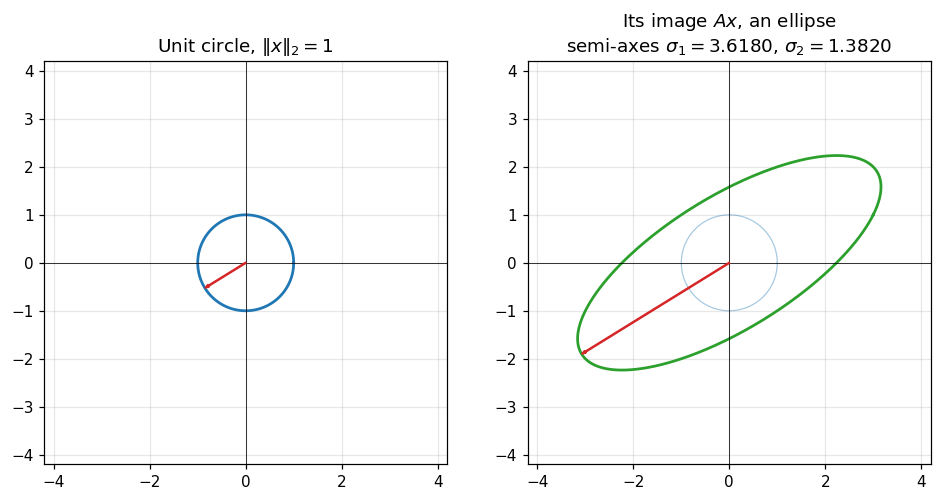

the red arrow is the direction that gets stretched most.
||A||_2 = 3.61803399 = sigma_1 = 3.61803399, the long semi-axis.
the SHORTEST semi-axis is sigma_2 = 1.38196601, the least stretching.
their ratio 2.618034 is kappa_2(A) = 2.618034,
which is how squashed the ellipse is. lesson 19 makes that the condition
number of solving Ax = b, and lesson 41 proves the identity.


In [13]:
A5 = np.array([[3.0, 1.0],
               [1.0, 2.0]])
theta = np.linspace(0, 2 * np.pi, 400)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
image = circle @ A5.T

U, S, Vt = np.linalg.svd(A5)
worst_in = Vt[0]
best_out = A5 @ worst_in

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.4, 5.0))
ax1.plot(circle[:, 0], circle[:, 1], "C0", lw=1.8)
ax1.arrow(0, 0, worst_in[0], worst_in[1], color="C3", width=0.02,
          length_includes_head=True, zorder=5)
ax1.set_title("Unit circle, $\\|x\\|_2 = 1$")
ax1.set_aspect("equal"); ax1.set_xlim(-4.2, 4.2); ax1.set_ylim(-4.2, 4.2)

ax2.plot(image[:, 0], image[:, 1], "C2", lw=1.8)
ax2.arrow(0, 0, best_out[0], best_out[1], color="C3", width=0.02,
          length_includes_head=True, zorder=5)
ax2.plot(circle[:, 0], circle[:, 1], "C0", lw=0.8, alpha=0.4)
ax2.set_title(f"Its image $Ax$, an ellipse\nsemi-axes $\\sigma_1 = {S[0]:.4f}$, "
              f"$\\sigma_2 = {S[1]:.4f}$")
ax2.set_aspect("equal"); ax2.set_xlim(-4.2, 4.2); ax2.set_ylim(-4.2, 4.2)
for a in (ax1, ax2):
    a.axhline(0, color="k", lw=0.5); a.axvline(0, color="k", lw=0.5)
plt.show()

print(f"the red arrow is the direction that gets stretched most.")
print(f"||A||_2 = {la.matrix_norm(A5,2):.8f} = sigma_1 = {S[0]:.8f}, the long semi-axis.")
print(f"the SHORTEST semi-axis is sigma_2 = {S[1]:.8f}, the least stretching.")
print(f"their ratio {S[0]/S[1]:.6f} is kappa_2(A) = {la.condition_number(A5,2):.6f},")
print("which is how squashed the ellipse is. lesson 19 makes that the condition")
print("number of solving Ax = b, and lesson 41 proves the identity.")
np.testing.assert_allclose(la.condition_number(A5, 2), S[0] / S[1])

**A matrix maps the unit sphere to an ellipsoid.** That single picture explains the 2-norm, the
condition number, and the SVD all at once. Keep it in mind for the rest of the course.

## 5. The Frobenius norm, and why it is not induced

The Frobenius norm treats the matrix as a long vector:

$$\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2}.$$

It is a perfectly good norm on matrices, it is submultiplicative, and it is cheap at $O(n^2)$.
It appears constantly later: in the Eckart-Young theorem (lesson 43), and in Broyden's
least-change derivation (lesson 14).

But it is **not induced by any vector norm**, and the proof is one line.

> **Proposition 15.3.** Every induced norm satisfies $\|I\| = 1$. But
> $\|I_n\|_F = \sqrt{n}$. So for $n \ge 2$ the Frobenius norm is not induced.
>
> *Proof.* $\|I\| = \max_{\|x\|=1}\|Ix\| = \max_{\|x\|=1}\|x\| = 1$. And $I_n$ has $n$ ones,
> so $\|I_n\|_F = \sqrt{n}$. $\square$

In [14]:
print(f"{'n':>6} {'||I||_1':>10} {'||I||_2':>10} {'||I||_inf':>11} {'||I||_F':>10}")
print("-" * 50)
for n in [1, 2, 4, 25, 100]:
    I = np.eye(n)
    print(f"{n:>6} {la.matrix_norm(I,1):>10.4f} {la.matrix_norm(I,2):>10.4f} "
          f"{la.matrix_norm(I,np.inf):>11.4f} {la.matrix_norm(I,'fro'):>10.4f}")

print()
print("the three induced norms all give exactly 1, always. Frobenius gives")
print("sqrt(n), which grows. that single column settles the question.")
for n in (1, 2, 7, 25, 64):
    I = np.eye(n)
    assert abs(la.matrix_norm(I, "fro") - np.sqrt(n)) < 1e-12 * np.sqrt(n)
    assert abs(la.matrix_norm(I, 2) - 1.0) < 1e-12

     n    ||I||_1    ||I||_2   ||I||_inf    ||I||_F
--------------------------------------------------
     1     1.0000     1.0000      1.0000     1.0000
     2     1.0000     1.0000      1.0000     1.4142
     4     1.0000     1.0000      1.0000     2.0000
    25     1.0000     1.0000      1.0000     5.0000
   100     1.0000     1.0000      1.0000    10.0000

the three induced norms all give exactly 1, always. Frobenius gives
sqrt(n), which grows. that single column settles the question.


It still relates usefully to the 2-norm:

$$\|A\|_2 \le \|A\|_F \le \sqrt{r}\,\|A\|_2, \qquad r = \operatorname{rank}(A),$$

because $\|A\|_F^2 = \sum_i\sigma_i^2$ while $\|A\|_2^2 = \sigma_1^2$. So they agree exactly for
a rank-one matrix and diverge as the singular values spread out.

In [15]:
print(f"{'matrix':>26} {'||A||_2':>10} {'||A||_F':>10} {'ratio':>8} {'sqrt(rank)':>11}")
print("-" * 68)
rng4 = np.random.default_rng(21)
dim = 6                                   # change this and every label follows
cases = [
    (f"rank 1, outer product",  np.outer(rng4.standard_normal(dim),
                                         rng4.standard_normal(dim))),
    (f"random {dim}x{dim}",     rng4.standard_normal((dim, dim))),
    (f"identity {dim}x{dim}",   np.eye(dim)),
    (f"tall {2*dim}x{dim}",     rng4.standard_normal((2 * dim, dim))),
    (f"wide {dim}x{2*dim}",     rng4.standard_normal((dim, 2 * dim))),
]
for name, M in cases:
    n2, nf = la.matrix_norm(M, 2), la.matrix_norm(M, "fro")
    r = np.linalg.matrix_rank(M)
    print(f"{name:>26} {n2:>10.5f} {nf:>10.5f} {nf/n2:>8.4f} {np.sqrt(r):>11.4f}")
    assert n2 <= nf + 1e-12 <= np.sqrt(r) * n2 + 1e-10

print()
print("row 1: rank one, so the two norms are EQUAL and the ratio is 1.")
print("row 3: the identity spreads its singular values as evenly as possible,")
print("so the ratio hits the upper bound sqrt(6) exactly.")

                    matrix    ||A||_2    ||A||_F    ratio  sqrt(rank)
--------------------------------------------------------------------
     rank 1, outer product    5.48581    5.48581   1.0000      1.0000
                random 6x6    4.25497    5.70291   1.3403      2.4495
              identity 6x6    1.00000    2.44949   2.4495      2.4495
                 tall 12x6    4.78021    7.70521   1.6119      2.4495
                 wide 6x12    4.46847    7.26275   1.6253      2.4495

row 1: rank one, so the two norms are EQUAL and the ratio is 1.
row 3: the identity spreads its singular values as evenly as possible,
so the ratio hits the upper bound sqrt(6) exactly.


## 6. Submultiplicativity, and how pessimistic it is

> **Theorem 15.4.** Every induced norm satisfies $\|A\mathbf{x}\| \le \|A\|\,\|\mathbf{x}\|$
> and $\|AB\| \le \|A\|\,\|B\|$.
>
> *Proof.* The first is the definition rearranged: $\|A\|$ is the maximum of
> $\|A\mathbf{x}\|/\|\mathbf{x}\|$, so that ratio never exceeds it. For the second, apply the
> first twice:
> $$\|AB\mathbf{x}\| \le \|A\|\,\|B\mathbf{x}\| \le \|A\|\,\|B\|\,\|\mathbf{x}\|,$$
> then take the maximum over unit $\mathbf{x}$. $\square$

**This is the single most used inequality in the rest of the course.** It is how a bound on an
input becomes a bound on an output.

It is also loose, often very loose, and knowing that is part of using it honestly.

In [16]:
print("how much slack is there in ||AB|| <= ||A|| ||B|| ?\n")
print(f"{'case':>30} {'||A|| ||B||':>13} {'||AB||':>11} {'ratio':>9}")
print("-" * 66)
rng5 = np.random.default_rng(33)
Q1 = og.random_orthogonal(8, rng5)
pairs = [
    ("A and A-inverse",          (M := rng5.standard_normal((8, 8)), np.linalg.inv(M))),
    ("two random matrices",      (rng5.standard_normal((8, 8)), rng5.standard_normal((8, 8)))),
    ("two orthogonal matrices",  (Q1, og.random_orthogonal(8, rng5))),
    ("A and a multiple of A",    (M2 := rng5.standard_normal((8, 8)), 3.0 * M2)),
]
for name, (P, Qm) in pairs:
    prod, joint = la.matrix_norm(P @ Qm, 2), la.matrix_norm(P, 2) * la.matrix_norm(Qm, 2)
    print(f"{name:>30} {joint:>13.4f} {prod:>11.4f} {prod/joint:>9.4f}")
    assert prod <= joint + 1e-10

print()
print("row 1 is the worst: A times A-inverse is the IDENTITY, norm 1, while")
print("the bound is kappa(A), which here is in the hundreds. the inequality is")
print("correct and useless for that pair.")
print()
print("row 3 is the best: orthogonal matrices have norm 1 and their product is")
print("orthogonal, so the bound is TIGHT. that is a preview of lesson 16.")

how much slack is there in ||AB|| <= ||A|| ||B|| ?

                          case   ||A|| ||B||      ||AB||     ratio
------------------------------------------------------------------
               A and A-inverse       14.7359      1.0000    0.0679
           two random matrices       24.3416     19.6805    0.8085
       two orthogonal matrices        1.0000      1.0000    1.0000
         A and a multiple of A       46.3644     35.0860    0.7567

row 1 is the worst: A times A-inverse is the IDENTITY, norm 1, while
the bound is kappa(A), which here is in the hundreds. the inequality is
correct and useless for that pair.

row 3 is the best: orthogonal matrices have norm 1 and their product is
orthogonal, so the bound is TIGHT. that is a preview of lesson 16.


### Why the looseness matters

Bounds built by applying submultiplicativity $k$ times pick up the slack $k$ times over. Watch
what happens to a matrix whose spectral radius is safely below 1.

In [17]:
A6 = np.array([[0.9, 4.0], [0.0, 0.8]])          # rho = 0.9, but ||A||_2 is much bigger
print("A =")
print(A6)
print(f"\nspectral radius rho(A) = {la.spectral_radius(A6):.6f}  (below 1, so A^k -> 0)")
print(f"norm ||A||_2           = {la.matrix_norm(A6, 2):.6f}  (above 1)\n")

print(f"{'k':>4} {'||A^k||_2':>14} {'bound ||A||^k':>16} {'overestimate by':>18}")
print("-" * 56)
norms = []
Ak = np.eye(A6.shape[0])                  # size comes from A6, not from a literal
for k in range(1, 121):
    Ak = Ak @ A6
    norms.append(la.matrix_norm(Ak, 2))
    if k in (1, 3, 6, 10, 20, 40, 80):
        print(f"{k:>4} {norms[-1]:>14.4e} {la.matrix_norm(A6,2)**k:>16.4e} "
              f"{la.matrix_norm(A6,2)**k/norms[-1]:>18.2e}")

norms = np.array(norms)
peak_k = int(np.argmax(norms)) + 1
below = int(np.argmax(norms < 1.0)) + 1
print(f"\n||A^k|| RISES to a peak of {norms.max():.4f} at k = {peak_k}, then decays.")
print(f"it does not drop below 1 until k = {below}.")
print()
print("so a spectral radius of 0.9 does NOT mean the norm shrinks every step.")
print("it shrinks eventually. between here and eventually there is a hump.")
assert peak_k > 1 and norms.max() > la.matrix_norm(A6, 2)   # there really is a hump
assert below > 30                                            # and it lasts a long time
assert norms[-1] < 1e-3 < norms.max()                        # but it does decay in the end

A =
[[0.9 4. ]
 [0.  0.8]]

spectral radius rho(A) = 0.900000  (below 1, so A^k -> 0)
norm ||A||_2           = 4.173756  (above 1)

   k      ||A^k||_2    bound ||A||^k    overestimate by
--------------------------------------------------------
   1     4.1738e+00       4.1738e+00           1.00e+00
   3     8.7255e+00       7.2708e+01           8.33e+00
   6     1.0788e+01       5.2864e+03           4.90e+02
  10     9.6591e+00       1.6042e+06           1.66e+05
  20     4.4036e+00       2.5736e+12           5.84e+11
  40     5.8610e-01       6.6234e+24           1.13e+25
  80     8.7410e-03       4.3870e+49           5.02e+51

||A^k|| RISES to a peak of 10.7882 at k = 6, then decays.
it does not drop below 1 until k = 35.

so a spectral radius of 0.9 does NOT mean the norm shrinks every step.
it shrinks eventually. between here and eventually there is a hump.


The three curves span nearly 40 decades, so the hump is invisible on one axis. It needs two.

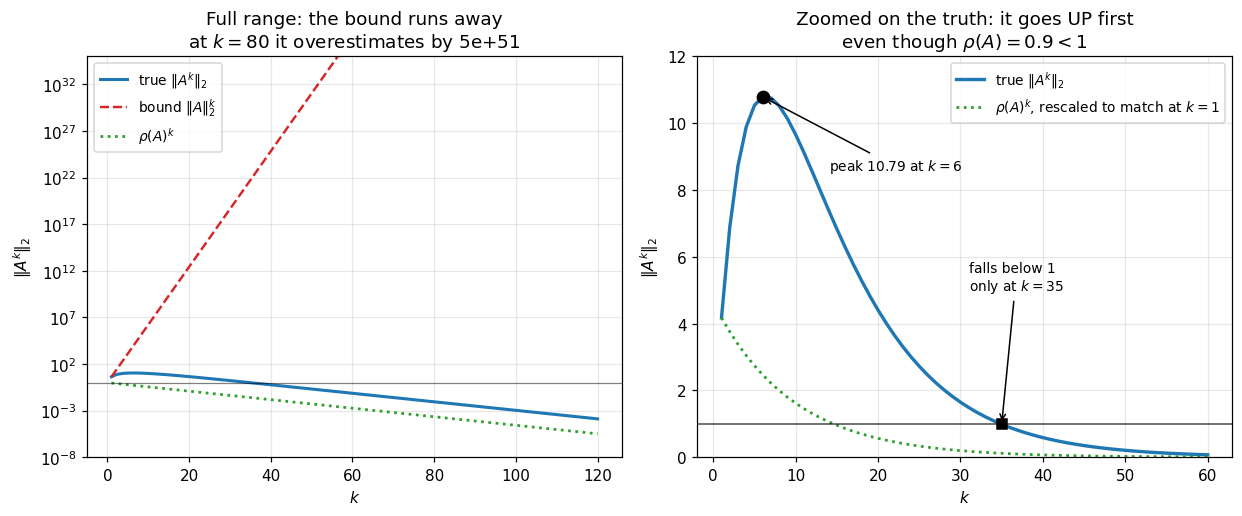

In [18]:
ks = np.arange(1, 121)
bound = la.matrix_norm(A6, 2) ** ks
rho_k = la.spectral_radius(A6) ** ks

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.4, 4.8))

# left: the full picture, showing how far the bound runs away
axL.semilogy(ks, norms, "C0-", lw=2, label=r"true $\|A^k\|_2$")
axL.semilogy(ks, bound, "C3--", lw=1.6, label=r"bound $\|A\|_2^k$")
axL.semilogy(ks, rho_k, "C2:", lw=1.8, label=r"$\rho(A)^k$")
axL.axhline(1.0, color="k", lw=0.8, alpha=0.5)
axL.set_xlabel("$k$"); axL.set_ylabel(r"$\|A^k\|_2$")
axL.set_ylim(1e-8, 1e35)
axL.set_title("Full range: the bound runs away\n"
              f"at $k=80$ it overestimates by {bound[79]/norms[79]:.0e}")
axL.legend(fontsize=9, loc="upper left")

# right: zoom on the truth, where the transient hump actually lives
axR.plot(ks[:60], norms[:60], "C0-", lw=2.2, label=r"true $\|A^k\|_2$")
axR.plot(ks[:60], rho_k[:60] * norms[0] / rho_k[0], "C2:", lw=1.8,
         label=r"$\rho(A)^k$, rescaled to match at $k=1$")
axR.axhline(1.0, color="k", lw=1.0, alpha=0.7)
axR.plot(peak_k, norms.max(), "ko", ms=8, zorder=5)
axR.annotate(f"peak {norms.max():.2f} at $k = {peak_k}$",
             xy=(peak_k, norms.max()), xytext=(peak_k + 8, norms.max() - 2.2),
             arrowprops=dict(arrowstyle="->", lw=1), fontsize=9)
axR.plot(below, norms[below - 1], "ks", ms=7, zorder=5)
axR.annotate(f"falls below 1\nonly at $k = {below}$",
             xy=(below, norms[below - 1]), xytext=(below - 4, 5.0),
             arrowprops=dict(arrowstyle="->", lw=1), fontsize=9)
axR.set_xlabel("$k$"); axR.set_ylabel(r"$\|A^k\|_2$")
axR.set_ylim(0, 12)
axR.set_title("Zoomed on the truth: it goes UP first\n"
              r"even though $\rho(A) = 0.9 < 1$")
axR.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

**What to take from this.** Three curves, three different meanings:

- The **bound** $\|A\|^k$ climbs forever. It is valid at every $k$, and by $k = 80$ it
  overestimates by 51 orders of magnitude.
- The **truth** climbs to about 10.8 at $k = 6$ and only falls below 1 at $k = 35$. That hump
  is real, not a bound artefact, and an iteration required to stay small would genuinely blow
  up during it.
- $\rho(A)^k$ sets the eventual **slope** and says nothing at all about the hump.

This is not a flaw in the inequality. It is what happens when you discard directional
information $k$ times in a row. The gap between the top curve and the middle one is the price
of using norms. The gap between the middle and the bottom is called **non-normality**, and
lesson 40 develops pseudospectra as the proper tool for it.


using norms; the gap between the middle and the bottom is called **non-normality**, and lesson
40 develops pseudospectra as the tool for it.

## 7. The spectral radius is not a norm

$$\rho(A) = \max_i |\lambda_i(A)|.$$

It fails the axioms, and it fails them badly:

In [19]:
N = np.array([[0.0, 100.0], [0.0, 0.0]])
print("N =\n", N)
print(f"\nrho(N)   = {la.spectral_radius(N):.6f}   <- ZERO, but N is not the zero matrix")
print(f"||N||_2  = {la.matrix_norm(N, 2):.6f}")
print("\nthat breaks positivity on its own. it also breaks the triangle inequality:")

M1 = np.array([[0.0, 1.0], [0.0, 0.0]])
M2 = np.array([[0.0, 0.0], [1.0, 0.0]])
print(f"   rho(M1) = {la.spectral_radius(M1):.4f}, rho(M2) = {la.spectral_radius(M2):.4f}, "
      f"sum = {la.spectral_radius(M1)+la.spectral_radius(M2):.4f}")
print(f"   rho(M1 + M2) = {la.spectral_radius(M1+M2):.4f}   <- LARGER than the sum")
assert la.spectral_radius(N) == 0.0
assert la.spectral_radius(M1 + M2) > la.spectral_radius(M1) + la.spectral_radius(M2)

N =
 [[  0. 100.]
 [  0.   0.]]

rho(N)   = 0.000000   <- ZERO, but N is not the zero matrix
||N||_2  = 100.000000

that breaks positivity on its own. it also breaks the triangle inequality:
   rho(M1) = 0.0000, rho(M2) = 0.0000, sum = 0.0000
   rho(M1 + M2) = 1.0000   <- LARGER than the sum


So why does anyone care about it? Because of two facts that a norm cannot give you.

> **Theorem 15.5.** For every induced norm, $\rho(A) \le \|A\|$. And **Gelfand's formula**
> says
> $$\lim_{k\to\infty}\|A^k\|^{1/k} = \rho(A)$$
> for every norm. Consequently $A^k \to 0$ **if and only if** $\rho(A) < 1$, regardless of
> what any norm says.

The first inequality means every norm is an upper bound for the spectral radius, and none of
them is generally tight. The second says that in the long run the spectral radius wins.

In [20]:
print("Gelfand's formula in action, on the A above with rho = 0.9\n")
print(f"{'k':>5} {'||A^k||^(1/k)':>16} {'gap to rho(A)':>16}")
print("-" * 40)
rho = la.spectral_radius(A6)
Ak = np.eye(A6.shape[0])
for k in range(1, 401):
    Ak = Ak @ A6
    if k in (1, 2, 5, 20, 100, 400):
        g = la.matrix_norm(Ak, 2) ** (1.0 / k)
        print(f"{k:>5} {g:>16.8f} {g - rho:>16.3e}")

print(f"\nrho(A) = {rho:.8f}")
print("the sequence starts at ||A|| = 4.1 and converges down to 0.9.")
print()
print("so the NORM decides the early behaviour and the SPECTRAL RADIUS decides")
print("the eventual rate. every iterative method in part 4 lives in that gap:")
print("the transient is governed by the norm, the asymptotic rate by rho.")
final = la.matrix_norm(Ak, 2) ** (1.0 / 400)
assert abs(final - rho) < 0.02

Gelfand's formula in action, on the A above with rho = 0.9

    k    ||A^k||^(1/k)    gap to rho(A)
----------------------------------------
    1       4.17375628        3.274e+00
    2       2.62249898        1.722e+00
    5       1.60147107        7.015e-01
   20       1.07693713        1.769e-01
  100       0.93382271        3.382e-02
  400       0.90833908        8.339e-03

rho(A) = 0.90000000
the sequence starts at ||A|| = 4.1 and converges down to 0.9.

so the NORM decides the early behaviour and the SPECTRAL RADIUS decides
the eventual rate. every iterative method in part 4 lives in that gap:
the transient is governed by the norm, the asymptotic rate by rho.


## 8. Norm-based error bounds: the machinery

Everything above exists to support one move, which is used in essentially every later proof.

> **The move.** If $\tilde{\mathbf{x}} = \mathbf{x} + \delta\mathbf{x}$ with
> $\|\delta\mathbf{x}\| \le \epsilon$, then
> $$\|A\tilde{\mathbf{x}} - A\mathbf{x}\| = \|A\,\delta\mathbf{x}\| \le \|A\|\,\epsilon.$$
> **A bound on the input becomes a bound on the output, multiplied by $\|A\|$.**

Turn it into relative form, which is the version that matters, by dividing:

$$\frac{\|A\,\delta\mathbf{x}\|}{\|A\mathbf{x}\|}
\le \|A\|\,\|A^{-1}\|\,\frac{\|\delta\mathbf{x}\|}{\|\mathbf{x}\|}
= \kappa(A)\,\frac{\|\delta\mathbf{x}\|}{\|\mathbf{x}\|},$$

using $\|\mathbf{x}\| = \|A^{-1}A\mathbf{x}\| \le \|A^{-1}\|\,\|A\mathbf{x}\|$ in the middle.

**That is lesson 06's governing inequality, now with a formula for $\kappa$.** Lesson 19 does
this properly for $A\mathbf{x} = \mathbf{b}$.

In [21]:
print("relative error in, relative error out\n")
rng6 = np.random.default_rng(5)
print(f"{'kappa_2(A)':>12} {'input rel. error':>18} {'output rel. error':>19} "
      f"{'amplification':>15} {'<= kappa?':>10}")
print("-" * 80)
for target_kappa in [1.0, 10.0, 1e3, 1e6, 1e9]:
    n = 8
    U, V = og.random_orthogonal(n, rng6), og.random_orthogonal(n, rng6)
    s = np.logspace(0, -np.log10(target_kappa), n)         # exact condition number
    A7 = U @ np.diag(s) @ V.T
    x7 = rng6.standard_normal(n)
    dx = rng6.standard_normal(n)
    dx = 1e-10 * dx / np.linalg.norm(dx) * np.linalg.norm(x7)

    rel_in = np.linalg.norm(dx) / np.linalg.norm(x7)
    rel_out = np.linalg.norm(A7 @ dx) / np.linalg.norm(A7 @ x7)
    k = la.condition_number(A7, 2)
    print(f"{k:>12.3e} {rel_in:>18.3e} {rel_out:>19.3e} {rel_out/rel_in:>15.3e} "
          f"{str(rel_out/rel_in <= k * 1.0001):>10}")
    assert rel_out / rel_in <= k * 1.0001

print()
print("the amplification never exceeds kappa, which is the theorem. it is also")
print("usually well BELOW kappa, because a random perturbation rarely points")
print("along the worst direction. kappa is a WORST CASE, and the gap between")
print("worst case and typical is a recurring theme, most sharply in lesson 18.")

relative error in, relative error out

  kappa_2(A)   input rel. error   output rel. error   amplification  <= kappa?
--------------------------------------------------------------------------------
   1.000e+00          1.000e-10           1.000e-10       1.000e+00       True
   1.000e+01          1.000e-10           8.165e-11       8.165e-01       True
   1.000e+03          1.000e-10           1.210e-10       1.210e+00       True
   1.000e+06          1.000e-10           8.460e-11       8.460e-01       True
   1.000e+09          1.000e-10           5.470e-11       5.470e-01       True

the amplification never exceeds kappa, which is the theorem. it is also
usually well BELOW kappa, because a random perturbation rarely points
along the worst direction. kappa is a WORST CASE, and the gap between
worst case and typical is a recurring theme, most sharply in lesson 18.


## 9. Complexity

| Quantity | Cost | Note |
|---|---|---|
| $\|\mathbf{x}\|_p$ | $O(n)$ | one pass |
| $\|A\|_1$, $\|A\|_\infty$ | $O(n^2)$ | read off the entries |
| $\|A\|_F$ | $O(n^2)$ | one pass |
| $\|A\|_2$ | $O(n^3)$ | needs an SVD |
| $\rho(A)$ | $O(n^3)$ | needs eigenvalues |
| $\kappa_p(A)$ by inversion | $O(n^3)$ | and you should not do this; see lesson 22 |
| $A\mathbf{x}$ | $2n^2$ flops | memory bound, BLAS-2 |
| $AB$ | $2n^3$ flops | compute bound, BLAS-3; lesson 08 measured the difference |

The gap between the $O(n^2)$ norms and the $O(n^3)$ ones is why the 1 and $\infty$ norms are
used for practical error estimates even when the 2-norm is the natural one for the theory.

## 10. Common mistakes

1. **Using $\rho(A) < 1$ as a bound on $\|A^k\|$ for small $k$.** Section 7: with
   $\rho = 0.9$ and $\|A\| = 4.1$, $\|A^k\|$ grows before it decays. The spectral radius is an
   asymptotic statement only.
2. **Assuming $\|A\|_F$ is an induced norm.** Section 5: $\|I\|_F = \sqrt{n}$ settles it.
   Bounds of the form $\|Ax\| \le \|A\|_F\|x\|$ are still valid, just not tight.
3. **Treating norm equivalence as free.** Section 3: the constants grow like $\sqrt{n}$ or
   $n$. In a PDE problem where $n$ is a million, they are not a detail.
4. **Chaining submultiplicativity many times.** Section 6: 12 applications overestimated by 8
   orders of magnitude.
5. **Computing $\kappa(A)$ by forming $A^{-1}$.** $O(n^3)$ and numerically wasteful. Lesson 22
   estimates it at $O(n^2)$ from a factorization you already have.
6. **Reporting an error without saying which norm.** For $n$ large the answer can differ by a
   factor of $n$.
7. **Reading $A\mathbf{x}$ row by row when a column argument is wanted.** Rank, range and
   solvability are all column statements.

## 11. Exercises

**Level 1, conceptual**

1.1 Explain in one sentence why $\operatorname{rank}(AB) \le \min(\operatorname{rank} A,
\operatorname{rank} B)$, using the column view.

1.2 A matrix has $\|A\|_2 = 5$ and $\|A^{-1}\|_2 = 4$. What is $\kappa_2(A)$, and what is the
most a relative input error of $10^{-8}$ can become?

1.3 Why does $\|I\|_F = \sqrt{n}$ prove the Frobenius norm is not induced?

**Level 2, mathematical**

2.1 Prove $\|A\|_\infty$ equals the maximum absolute row sum, both directions: show the row sum
is an upper bound, then construct a vector attaining it.

2.2 Prove $\|A\|_1 = \|A^T\|_\infty$.

2.3 Prove $\rho(A) \le \|A\|$ for every induced norm. Use an eigenvector.

2.4 Prove $\|A\|_2 \le \sqrt{\|A\|_1\|A\|_\infty}$. This gives a cheap $O(n^2)$ bound on the
expensive norm. Measure how tight it is.

2.5 Show that $\|A\|_2 = \|A^T\|_2$, but that $\|A\|_1 \ne \|A\|_\infty$ in general. What is it
about the 2-norm that makes it transpose invariant?

**Level 3, computational**

3.1 Implement $\|A\|_2$ by the **power method** on $A^TA$, and compare against
`numpy.linalg.svd` for speed and accuracy on matrices up to $1000 \times 1000$. Lesson 36
develops the power method properly.

3.2 Write a function that, given $A$ and $p \in \{1, \infty\}$, returns both $\|A\|_p$ and a
unit vector attaining it. Verify the ratio equals the norm to machine precision.

3.3 The naive 2-norm in `nalib.linalg.vector_norm` squares the entries first, so it overflows
for entries near $10^{200}$. Reproduce the overflow, then implement the scaled version that
`numpy.linalg.norm` uses, and show yours agrees with NumPy where the naive one returns `inf`.

**Level 4, experimental**

4.1 For random $n \times n$ matrices with $n$ from 2 to 200, measure the ratio
$\|A\|_F/\|A\|_2$ and compare against the bound $\sqrt{n}$. How does the typical ratio grow?

4.2 Measure the sharpness of submultiplicativity as a function of dimension: for random $A, B$
of size $n$, plot $\|AB\|/(\|A\|\|B\|)$ against $n$. Does the bound get tighter or looser?

4.3 Reproduce lesson 08's matrix multiply timing with the three views of section 2. Confirm
that they produce identical answers and very different runtimes, and explain the ordering from
memory layout.

**Level 5, advanced**

5.1 The **numerical radius** $r(A) = \max_{\|x\|=1}|x^*Ax|$ satisfies
$\rho(A) \le r(A) \le \|A\|_2 \le 2r(A)$. Verify all three inequalities numerically, find
matrices attaining each, and explain what $r(A)$ measures that neither $\rho$ nor $\|\cdot\|_2$
does.

5.2 A norm is **absolute** when $\|x\|$ depends only on $|x_i|$, and **monotone** when
$|x_i| \le |y_i|$ for all $i$ implies $\|x\| \le \|y\|$. Prove these two properties are
equivalent. Which of the norms in this lesson have them?

5.3 **Non-normal matrices.** For a normal matrix ($A^*A = AA^*$) the 2-norm equals the spectral
radius. Investigate how far apart they can get for non-normal matrices, construct a family
where the ratio grows without bound, and connect it to the transient growth in section 6.
Lesson 40 develops pseudospectra as the proper tool for this.

## 12. Key takeaways

- **$A\mathbf{x}$ is a linear combination of the columns of $A$.** The range is the column
  span, solvability means $\mathbf{b}$ lies in it, and rank is the number of independent
  columns. Reading products by columns makes all three immediate.
- **$AB$ is a sum of rank-one outer products.** Measured in section 2: adding the terms one at
  a time raises the rank by one each time. This is the form the SVD produces and low-rank
  approximation truncates.
- A **norm** satisfies positivity, homogeneity and the triangle inequality. The "$p = 0.5$
  norm" fails the third by a wide margin, measured in section 3, because its unit ball is not
  convex.
- **Induced norms measure the largest stretch**, $\|A\|_p = \max_{\|x\|_p=1}\|Ax\|_p$. Closed
  forms exist for $p = 1, \infty$ at $O(n^2)$ and for $p = 2$ at $O(n^3)$. Sampling directions
  instead undershoots, recovering only about two thirds of the norm at $n = 100$ even with
  20000 samples.
- **A matrix maps the unit sphere to an ellipsoid.** The semi-axes are the singular values,
  $\|A\|_2$ is the longest, and $\kappa_2(A)$ is the ratio of longest to shortest.
- **The Frobenius norm is not induced**, because $\|I\|_F = \sqrt{n}$ while every induced norm
  gives exactly 1. It still satisfies $\|A\|_2 \le \|A\|_F \le \sqrt{r}\|A\|_2$, with equality
  on the left for rank-one matrices, measured in section 5.
- **Submultiplicativity is the workhorse and it is loose.** Measured on a matrix with
  $
ho = 0.9$: the bound $\|A\|^k$ climbs forever and overestimates by 51 orders of
  magnitude at $k = 80$, while $\|A^k\|$ itself humps up to 10.8 at $k = 6$ and only drops
  below 1 at $k = 35$. Three different curves, three different meanings.
- **The spectral radius is not a norm.** A nonzero matrix can have $\rho = 0$, and $\rho$ can
  exceed the sum for a sum of matrices. But $\rho(A) \le \|A\|$ always, and Gelfand's formula
  says $\|A^k\|^{1/k} \to \rho(A)$, so $\rho$ decides whether powers converge. The norm governs
  the transient, $\rho$ governs the rate.
- **The core move**: $\|\delta\mathbf{x}\| \le \epsilon$ gives $\|A\delta\mathbf{x}\| \le
  \|A\|\epsilon$, and in relative terms the amplification is at most $\kappa(A)$. Measured
  across five condition numbers spanning $10^0$ to $10^9$, never violated and usually well
  under, because a random perturbation rarely points the worst way.

## Where this goes next

Lesson 16 takes the one class of matrices for which $\kappa_2 = 1$ exactly, the orthogonal
ones, and builds the projector machinery on top. Lesson 17 uses norms to count the cost of
elimination and to state the stability of triangular solves. Lesson 19 turns section 8's
inequality into the conditioning theory of $A\mathbf{x} = \mathbf{b}$. Part 4 uses the spectral
radius of section 7 as its convergence criterion throughout.

Solutions are in [`solutions/part03_direct_linear_systems.md`](../solutions/part03_direct_linear_systems.md).